# Fixed topological objects: homology and Laplacians on a hexagon

This notebook gives four independent fixed examples:

1. **Graph** — a six-cycle,
2. **Simplicial complex** — a closed shell with $\beta_2=1$,
3. **Hyperdigraph** — ordered hyperedges with one ambient vertex omitted from dimension 0, and
4. **Interaction complex** — two fixed factors with two shared vertex identities.

Each section starts with a small dictionary whose keys `0`, `1`, and `2` contain the elements in those dimensions. The six coordinates are written out directly so they are easy to change. Coordinates control only the drawing; the dictionaries define the topology.

In [12]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans', 'Liberation Sans'],
    'font.size': 8,
    'axes.titlesize': 9,
    'axes.titleweight': 'bold',
    'axes.labelsize': 8,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'legend.frameon': False,
    'figure.facecolor': 'white',
    'savefig.facecolor': 'white',
    'svg.fonttype': 'none',
    'pdf.fonttype': 42,
})

project_root = Path.cwd()
if project_root.name == 'examples':
    project_root = project_root.parent

from topokit import PointCloud, Topology, __version__, workflows
from topokit.builders import interaction as interaction_builder
from topokit.core import hyperdigraph, simplicial
from topokit import visualization as viz

output_dir = project_root / 'examples' / 'output' / 'fixed_topological_objects_homology_laplacian'
output_dir.mkdir(parents=True, exist_ok=True)
tol = 1e-10
style = viz.StationaryStyle()

print(f'TopoKit {__version__}; output folder: {output_dir.relative_to(project_root)}')

TopoKit 0.3.0; output folder: examples/output/fixed_topological_objects_homology_laplacian


## Coordinates and calculation convention

For a fixed chain complex with boundary matrices $B_q$, the ordinary real Hodge Laplacian is

$$L_q = B_q^{\mathsf T}B_q + B_{q+1}B_{q+1}^{\mathsf T}.$$

TopoKit computes Betti numbers here over $\mathrm{GF}(2)$ and Laplacians over $\mathbb{R}$. For these four examples, the nullity of $L_q$ equals $\beta_q$, although that agreement is not automatic for every chain complex. Each matrix is shown in the basis returned by TopoKit.

A $q$-dimensional element is written as a tuple of $q+1$ vertex labels. In the simplicial example, a 2-simplex is one filled triangle, while $H_2$ records closed 2-cycles modulo 2-boundaries.

The next cell is the only place where point coordinates are defined. The helper cell after it normally does not need editing.

In [13]:
# Edit these six rows to move points in every drawing.
points = {
    0: (2.0, 0.000000),
    1: (1.0, 1.732051),
    2: (-1.0, 1.732051),
    3: (-2.0, 0.000000),
    4: (-1.0, -1.732051),
    5: (1.0, -1.732051),
}
vertices = tuple(points)

display(pd.DataFrame.from_dict(points, orient='index', columns=('x', 'y')).rename_axis('vertex'))

,x,y
vertex,,
0,2.0,0.000000
1,1.0,1.732051
2,-1.0,1.732051
3,-2.0,0.000000
4,-1.0,-1.732051
5,1.0,-1.732051


In [14]:
# Reusable display/export helpers; the examples below contain the editable topology.
def make_cloud(vertex_ids=vertices):
    vertex_ids = tuple(vertex_ids)
    return PointCloud(
        [points[vertex] for vertex in vertex_ids], ids=vertex_ids,
        metadata={'coordinate_units': 'arbitrary units'},
    )

cloud = make_cloud()

def flatten_cells(cells):
    return tuple(cell for dimension in sorted(cells) for cell in cells[dimension])

def fixed_complex(cells):
    # Simplicial builders store a fixed complex as {cell: one shared value}.
    return {cell: 0.0 for cell in flatten_cells(cells)}

def show_cell_counts(cells):
    counts = {dimension: len(layer) for dimension, layer in cells.items()}
    display(pd.Series(counts, name='number of cells').rename_axis('dimension').to_frame())

def dense_matrix(matrix):
    if matrix is None:
        return np.empty((0, 0), dtype=float)
    return matrix.toarray() if hasattr(matrix, 'toarray') else np.asarray(matrix, dtype=float)

def basis_label(item):
    # Hyperdigraph coordinate bases are returned as labelled linear combinations.
    if (isinstance(item, tuple) and len(item) == 1 and
            isinstance(item[0], tuple) and len(item[0]) == 2 and
            isinstance(item[0][0], tuple) and abs(float(item[0][1]) - 1.0) <= tol):
        return str(item[0][0])
    return str(item)

def show_analysis(name, result):
    """Display and save the homology and Laplacians returned by TopoKit."""
    tables, rows = {}, []
    for q, spectrum in result.spectra.items():
        matrix = dense_matrix(spectrum.matrix)
        labels = tuple(f'{index}: {basis_label(item)}' for index, item in enumerate(spectrum.basis))
        tables[q] = pd.DataFrame(matrix, index=labels, columns=labels)
        rows.append({
            'dimension': q,
            'Betti over GF(2)': result.homology.betti_numbers[q],
            'basis size': len(spectrum.basis),
            'real nullity': spectrum.nullity,
            'eigenvalues': np.array2string(np.round(spectrum.eigenvalues, 6), separator=', '),
        })
        tables[q].to_csv(output_dir / f'{name}_L{q}_matrix.csv')
    summary = pd.DataFrame(rows).set_index('dimension')
    summary.to_csv(output_dir / f'{name}_homology_laplacian_summary.csv')
    display(summary)
    for q, table in tables.items():
        print(f'L{q} in the returned basis; shape={table.shape}')
        if table.empty:
            print('  empty operator: this chain group has no basis elements')
        else:
            display(table.round(6))

def label_vertices(ax, vertex_ids=vertices):
    for vertex in vertex_ids:
        x, y = points[vertex]
        text = ax.text(
            1.09 * x, 1.09 * y, str(vertex), ha='center', va='center',
            fontsize=7.5, fontweight='bold', color=style.point_color, zorder=20,
        )
        text.set_gid(f'topokit-fixed-label-{vertex}')

def save_figure(fig, stem):
    viz.save_figure(fig, output_dir / f'{stem}.svg')
    viz.save_figure(fig, output_dir / f'{stem}.png', dpi=300)
    display(fig)
    plt.close(fig)

## 1. Graph

`graph_cells` lists the six vertices in dimension 0 and the six undirected edges in dimension 1. Dimension 2 is empty. The resulting six-cycle has $(\beta_0,\beta_1,\beta_2)=(1,1,0)$.

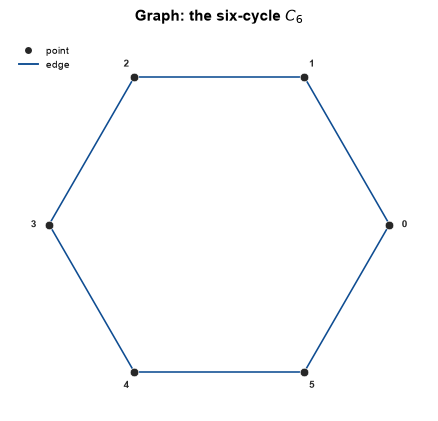

,number of cells
dimension,
0,6
1,6
2,0


In [15]:
# Edit the cells in each dimension.
graph_cells = {
    0: ((0,), (1,), (2,), (3,), (4,), (5,)),
    1: ((0, 1), (1, 2), (2, 3), (3, 4), (4, 5), (0, 5)),
    2: (),
}

graph_topology = Topology(
    'simplicial', simplicial.SimplicialComplex(fixed_complex(graph_cells)), cloud,
)

fig, ax = plt.subplots(figsize=(4.7, 4.1), constrained_layout=True)
viz.plot_stationary_graph(
    graph_topology, ax=ax, title='Graph: the six-cycle $C_6$',
    style=style, show_axes=False, node_size=38, edge_width=1.15, limits_margin=0.46,
)
label_vertices(ax)
save_figure(fig, '01_graph')

show_cell_counts(graph_cells)

In [16]:
graph_result = workflows.analyze_stationary(
    graph_topology, dimensions=(0, 1, 2), return_matrices=True,
)
show_analysis('graph', graph_result)

,Betti over GF(2),basis size,real nullity,eigenvalues
dimension,,,,
0,1,6,1,"[-0., 1., 1., 3., 3., 4.]"
1,1,6,1,"[0., 1., 1., 3., 3., 4.]"
2,0,0,0,[]


L0 in the returned basis; shape=(6, 6)


,"0: (0,)","1: (1,)","2: (2,)","3: (3,)","4: (4,)","5: (5,)"
"0: (0,)",2.0,-1.0,0.0,0.0,0.0,-1.0
"1: (1,)",-1.0,2.0,-1.0,0.0,0.0,0.0
"2: (2,)",0.0,-1.0,2.0,-1.0,0.0,0.0
"3: (3,)",0.0,0.0,-1.0,2.0,-1.0,0.0
"4: (4,)",0.0,0.0,0.0,-1.0,2.0,-1.0
"5: (5,)",-1.0,0.0,0.0,0.0,-1.0,2.0


L1 in the returned basis; shape=(6, 6)


,"0: (0, 1)","1: (0, 5)","2: (1, 2)","3: (2, 3)","4: (3, 4)","5: (4, 5)"
"0: (0, 1)",2.0,1.0,-1.0,0.0,0.0,0.0
"1: (0, 5)",1.0,2.0,0.0,0.0,0.0,1.0
"2: (1, 2)",-1.0,0.0,2.0,-1.0,0.0,0.0
"3: (2, 3)",0.0,0.0,-1.0,2.0,-1.0,0.0
"4: (3, 4)",0.0,0.0,0.0,-1.0,2.0,-1.0
"5: (4, 5)",0.0,1.0,0.0,0.0,-1.0,2.0


L2 in the returned basis; shape=(0, 0)
  empty operator: this chain group has no basis elements


## 2. Simplicial complex

`simplicial_cells` lists all vertices, edges, and triangular faces of a closed octahedral shell. The fixed complex has $(\beta_0,\beta_1,\beta_2)=(1,0,1)$. Some faces overlap in this flat drawing; `simplicial_cells` defines the complex, while `points` defines only its display.

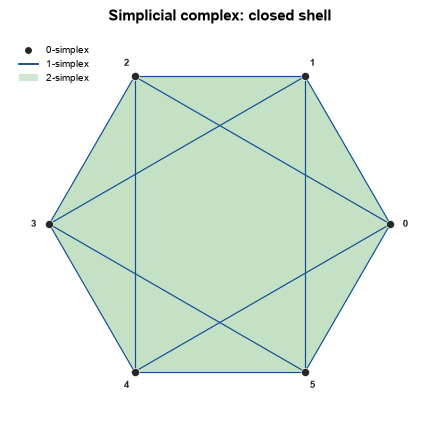

,number of cells
dimension,
0,6
1,12
2,8


In [17]:
# Edit the cells in each dimension.
simplicial_cells = {
    0: ((0,), (1,), (2,), (3,), (4,), (5,)),
    1: (
        (0, 1), (0, 2), (0, 4), (0, 5),
        (1, 2), (1, 3), (1, 5), (2, 3),
        (2, 4), (3, 4), (3, 5), (4, 5),
    ),
    2: (
        (0, 1, 2), (0, 1, 5), (0, 2, 4), (0, 4, 5),
        (1, 2, 3), (1, 3, 5), (2, 3, 4), (3, 4, 5),
    ),
}

simplicial_topology = Topology(
    'simplicial', simplicial.SimplicialComplex(fixed_complex(simplicial_cells)), cloud,
)

fig, ax = plt.subplots(figsize=(4.7, 4.1), constrained_layout=True)
viz.plot_stationary_simplicial(
    simplicial_topology, ax=ax, dimensions=(0, 1, 2),
    title='Simplicial complex: closed shell', style=style, show_axes=False,
    node_size=34, edge_width=0.85, face_alpha=0.24, limits_margin=0.46,
)
label_vertices(ax)
save_figure(fig, '02_simplicial_complex')
show_cell_counts(simplicial_cells)

In [18]:
simplicial_result = workflows.analyze_stationary(
    simplicial_topology, dimensions=(0, 1, 2), return_matrices=True,
)
show_analysis('simplicial', simplicial_result)

,Betti over GF(2),basis size,real nullity,eigenvalues
dimension,,,,
0,1,6,1,"[0., 4., 4., 4., 6., 6.]"
1,0,12,0,"[2., 2., 2., 4., 4., 4., 4., 4., 4., 6., 6., 6.]"
2,1,8,1,"[0., 2., 2., 2., 4., 4., 4., 6.]"


L0 in the returned basis; shape=(6, 6)


,"0: (0,)","1: (1,)","2: (2,)","3: (3,)","4: (4,)","5: (5,)"
"0: (0,)",4.0,-1.0,-1.0,0.0,-1.0,-1.0
"1: (1,)",-1.0,4.0,-1.0,-1.0,0.0,-1.0
"2: (2,)",-1.0,-1.0,4.0,-1.0,-1.0,0.0
"3: (3,)",0.0,-1.0,-1.0,4.0,-1.0,-1.0
"4: (4,)",-1.0,0.0,-1.0,-1.0,4.0,-1.0
"5: (5,)",-1.0,-1.0,0.0,-1.0,-1.0,4.0


L1 in the returned basis; shape=(12, 12)


,"0: (0, 1)","1: (0, 2)","2: (0, 4)","3: (0, 5)","4: (1, 2)","5: (1, 3)","6: (1, 5)","7: (2, 3)","8: (2, 4)","9: (3, 4)","10: (3, 5)","11: (4, 5)"
"0: (0, 1)",4.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
"1: (0, 2)",0.0,4.0,0.0,1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0
"2: (0, 4)",1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
"3: (0, 5)",0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
"4: (1, 2)",0.0,0.0,0.0,0.0,4.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0
"5: (1, 3)",-1.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,-1.0,0.0,0.0
"6: (1, 5)",0.0,0.0,0.0,0.0,1.0,0.0,4.0,0.0,0.0,0.0,0.0,1.0
"7: (2, 3)",0.0,-1.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,-1.0,0.0
"8: (2, 4)",0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,4.0,0.0,0.0,-1.0
"9: (3, 4)",0.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,4.0,0.0,0.0


L2 in the returned basis; shape=(8, 8)


,"0: (0, 1, 2)","1: (0, 1, 5)","2: (0, 2, 4)","3: (0, 4, 5)","4: (1, 2, 3)","5: (1, 3, 5)","6: (2, 3, 4)","7: (3, 4, 5)"
"0: (0, 1, 2)",3.0,1.0,-1.0,0.0,1.0,0.0,0.0,0.0
"1: (0, 1, 5)",1.0,3.0,0.0,1.0,0.0,-1.0,0.0,0.0
"2: (0, 2, 4)",-1.0,0.0,3.0,-1.0,0.0,0.0,-1.0,0.0
"3: (0, 4, 5)",0.0,1.0,-1.0,3.0,0.0,0.0,0.0,1.0
"4: (1, 2, 3)",1.0,0.0,0.0,0.0,3.0,-1.0,1.0,0.0
"5: (1, 3, 5)",0.0,-1.0,0.0,0.0,-1.0,3.0,0.0,-1.0
"6: (2, 3, 4)",0.0,0.0,-1.0,0.0,1.0,0.0,3.0,1.0
"7: (3, 4, 5)",0.0,0.0,0.0,1.0,0.0,-1.0,1.0,3.0


## 3. Hyperdigraph

A tuple containing $q+1$ vertices is a $q$-dimensional ordered hyperedge. `hyperdigraph_cells` groups these tuples by dimension. Vertex `0` is part of `points` and occurs in larger hyperedges, but singleton `(0,)` is omitted. The hollow point marks this omission.

TopoKit analyzes exactly the listed ordered hyperedges. This example has Betti numbers $(1,1,0)$ and $L_2$ spectrum $\{2,4\}$.

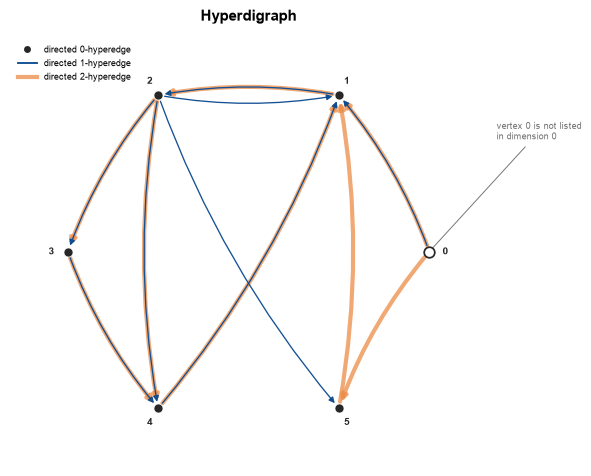

,number of cells
dimension,
0,5
1,8
2,4


In [19]:
# Edit the ordered hyperedges in each dimension.
hyperdigraph_cells = {
    0: ((1,), (2,), (3,), (4,), (5,)),
    1: ((0, 1), (1, 2), (2, 1), (2, 3),
        (2, 4), (2, 5), (3, 4), (4, 1)),
    2: ((0, 1, 2), (0, 5, 1), (2, 3, 4), (2, 4, 1)),
}
hyperdigraph_topology = Topology(
    'hyperdigraph',
    hyperdigraph.Hyperdigraph(
        vertices, flatten_cells(hyperdigraph_cells),
        include_all_vertices=False,
    ),
    cloud,
    {'route': 'hyperdigraph', 'source': 'explicit_dictionary',
     'max_analysis_dimension': 2},
)

omitted_vertices = tuple(
    vertex for vertex in vertices if (vertex,) not in hyperdigraph_cells[0]
)

fig, ax = plt.subplots(figsize=(5.8, 4.8), constrained_layout=True)
viz.plot_stationary_hyperdigraph(
    hyperdigraph_topology, ax=ax, dimensions=(0, 1, 2), title='Hyperdigraph',
    style=style, color_by_weights=False, colorbar=False, show_axes=False,
    node_size=42, arrow_size=8.3, limits_margin=0.64,
)
if omitted_vertices:
    vertex = omitted_vertices[0]
    coordinate = np.asarray(points[vertex])
    ax.scatter(
        *coordinate, s=58, facecolors='white', edgecolors=style.point_color,
        linewidths=1.25, zorder=18,
    )
    ax.annotate(
        f'vertex {vertex} is not listed\nin dimension 0',
        xy=coordinate, xytext=(1.02, 0.78), textcoords='axes fraction',
        arrowprops={'arrowstyle': '-', 'color': style.annotation_color, 'lw': 0.7},
        fontsize=6.8, color=style.annotation_color, ha='left', va='center',
    )
label_vertices(ax)
save_figure(fig, '03_hyperdigraph')

show_cell_counts(hyperdigraph_cells)

In [20]:
hyperdigraph_result = workflows.analyze_stationary(
    hyperdigraph_topology, dimensions=(0, 1, 2), return_matrices=True,
)
show_analysis('hyperdigraph', hyperdigraph_result)

,Betti over GF(2),basis size,real nullity,eigenvalues
dimension,,,,
0,1,5,1,"[-0. , 1.043967, 2.332031, 4.079714, ..."
1,1,7,1,"[-0. , 1.043967, 2. , 2.332031, ..."
2,0,2,0,"[2., 4.]"


L0 in the returned basis; shape=(5, 5)


,"0: (1,)","1: (2,)","2: (3,)","3: (4,)","4: (5,)"
"0: (1,)",3.0,-2.0,0.0,-1.0,0.0
"1: (2,)",-2.0,5.0,-1.0,-1.0,-1.0
"2: (3,)",0.0,-1.0,2.0,-1.0,0.0
"3: (4,)",-1.0,-1.0,-1.0,3.0,0.0
"4: (5,)",0.0,-1.0,0.0,0.0,1.0


L1 in the returned basis; shape=(7, 7)


,"0: (1, 2)","1: (2, 1)","2: (2, 3)","3: (2, 4)","4: (2, 5)","5: (3, 4)","6: (4, 1)"
"0: (1, 2)",2.0,-2.0,-1.0,-1.0,-1.0,0.0,-1.0
"1: (2, 1)",-2.0,3.0,1.0,0.0,1.0,0.0,0.0
"2: (2, 3)",-1.0,1.0,3.0,0.0,1.0,0.0,0.0
"3: (2, 4)",-1.0,0.0,0.0,4.0,1.0,0.0,0.0
"4: (2, 5)",-1.0,1.0,1.0,1.0,2.0,0.0,0.0
"5: (3, 4)",0.0,0.0,0.0,0.0,0.0,3.0,-1.0
"6: (4, 1)",-1.0,0.0,0.0,0.0,0.0,-1.0,3.0


L2 in the returned basis; shape=(2, 2)


,"0: (2, 3, 4)","1: (2, 4, 1)"
"0: (2, 3, 4)",3.0,-1.0
"1: (2, 4, 1)",-1.0,3.0


## 4. Interaction complex

`interaction_cells` contains two fixed factor complexes. Factor A uses vertices `(0, 1, 2, 3)` and factor B uses `(0, 5, 4, 3)`. Both are cycles containing edge `(0,3)`. Labels `0` and `3` occur in both factors, so the orange rings mark two shared vertex identities.

The interaction complex combines matching simplices from the two factors; it is not the geometric union of the drawings. Its Betti numbers are $(0,0,1)$. Here $\beta_0=0$ describes the interaction complex, not the number of connected components in either factor.

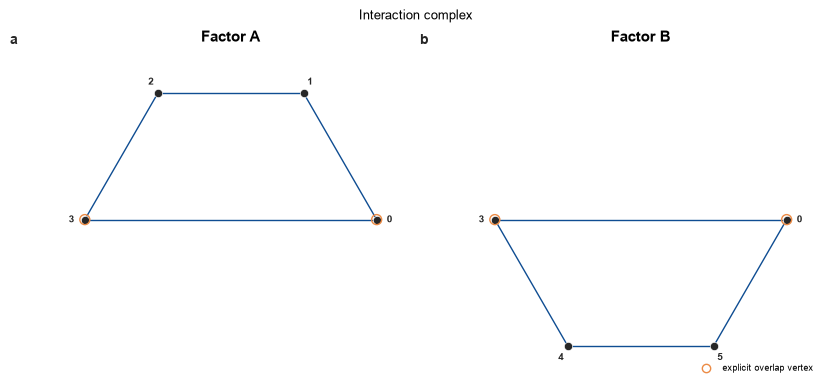

,number of cells
dimension,
0,4
1,4
2,0


,number of cells
dimension,
0,4
1,4
2,0


Shared vertex pairs: ((0, 0), (3, 3))


In [21]:
# Edit the cells in each factor and dimension.
interaction_cells = {
    'factor_a': {
        0: ((0,), (1,), (2,), (3,)),
        1: ((0, 1), (1, 2), (2, 3), (0, 3)),
        2: (),
    },
    'factor_b': {
        0: ((0,), (5,), (4,), (3,)),
        1: ((0, 5), (4, 5), (3, 4), (0, 3)),
        2: (),
    },
}

interaction_topology = interaction_builder.from_complexes(
    fixed_complex(interaction_cells['factor_a']),
    fixed_complex(interaction_cells['factor_b']),
    max_dimension=2,
)
factor_a_vertices = tuple(cell[0] for cell in interaction_cells['factor_a'][0])
factor_b_vertices = tuple(cell[0] for cell in interaction_cells['factor_b'][0])
interaction_topology.cloud = (
    make_cloud(factor_a_vertices), make_cloud(factor_b_vertices),
)

fig, axes = plt.subplots(1, 2, figsize=(8.2, 3.8), constrained_layout=True)
viz.plot_stationary_interaction(
    interaction_topology, dimensions=(0, 1, 2), axes=axes,
    title='Interaction complex', factor_titles=('Factor A', 'Factor B'),
    style=style, show_axes=False, node_size=35, edge_width=1.0,
    limits_margin=0.48, legend=True,
)
for axis, vertex_ids in zip(axes, (factor_a_vertices, factor_b_vertices)):
    label_vertices(axis, vertex_ids)
save_figure(fig, '04_interaction_complex')

show_cell_counts(interaction_cells['factor_a'])
show_cell_counts(interaction_cells['factor_b'])
print('Shared vertex pairs:', interaction_topology.metadata['overlap_pairs'])

In [22]:
interaction_result = workflows.analyze_stationary(
    interaction_topology, dimensions=(0, 1, 2), return_matrices=True,
)
show_analysis('interaction', interaction_result)

,Betti over GF(2),basis size,real nullity,eigenvalues
dimension,,,,
0,0,2,0,"[4., 4.]"
1,0,8,0,"[0.585786, 2. , 2. , 2.585786, 3.414..."
2,1,7,1,"[0. , 0.585786, 2. , 2. , 2.585..."


L0 in the returned basis; shape=(2, 2)


,"0: ((0,), (0,))","1: ((3,), (3,))"
"0: ((0,), (0,))",4.0,0.0
"1: ((3,), (3,))",0.0,4.0


L1 in the returned basis; shape=(8, 8)


,"0: ((0,), (0, 3))","1: ((0,), (0, 5))","2: ((3,), (0, 3))","3: ((3,), (3, 4))","4: ((0, 1), (0,))","5: ((0, 3), (0,))","6: ((0, 3), (3,))","7: ((2, 3), (3,))"
"0: ((0,), (0, 3))",3.0,1.0,-1.0,0.0,0.0,0.0,1.0,0.0
"1: ((0,), (0, 5))",1.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
"2: ((3,), (0, 3))",-1.0,0.0,3.0,-1.0,0.0,1.0,0.0,0.0
"3: ((3,), (3, 4))",0.0,0.0,-1.0,3.0,0.0,0.0,0.0,0.0
"4: ((0, 1), (0,))",0.0,0.0,0.0,0.0,3.0,1.0,0.0,0.0
"5: ((0, 3), (0,))",0.0,0.0,1.0,0.0,1.0,3.0,-1.0,0.0
"6: ((0, 3), (3,))",1.0,0.0,0.0,0.0,0.0,-1.0,3.0,1.0
"7: ((2, 3), (3,))",0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0


L2 in the returned basis; shape=(7, 7)


,"0: ((0, 1), (0, 3))","1: ((0, 1), (0, 5))","2: ((0, 3), (0, 3))","3: ((0, 3), (0, 5))","4: ((0, 3), (3, 4))","5: ((2, 3), (0, 3))","6: ((2, 3), (3, 4))"
"0: ((0, 1), (0, 3))",2.0,1.0,1.0,0.0,0.0,0.0,0.0
"1: ((0, 1), (0, 5))",1.0,2.0,0.0,1.0,0.0,0.0,0.0
"2: ((0, 3), (0, 3))",1.0,0.0,4.0,1.0,-1.0,1.0,0.0
"3: ((0, 3), (0, 5))",0.0,1.0,1.0,2.0,0.0,0.0,0.0
"4: ((0, 3), (3, 4))",0.0,0.0,-1.0,0.0,2.0,0.0,1.0
"5: ((2, 3), (0, 3))",0.0,0.0,1.0,0.0,0.0,2.0,-1.0
"6: ((2, 3), (3, 4))",0.0,0.0,0.0,0.0,1.0,-1.0,2.0


## Rerunning the notebook

This notebook uses the existing `Python (topokit)` Conda kernel. From the TopoKit project root:

```bash
conda activate topokit
jupyter lab examples/fixed_topological_objects_analysis.ipynb
```

Edit `points` to move vertices in the drawings. Edit `graph_cells`, `simplicial_cells`, `hyperdigraph_cells`, or `interaction_cells` to change an object. Each topology dictionary groups its cells by dimension, so a fixed example can be adjusted in one place.